In [1]:
# import the usual resources
import matplotlib.pyplot as plt
import numpy as np

# import utilities to keep workspaces alive during model training
#from workspace_utils import active_session

# watch for any changes in model.py, if it changes, re-load it automatically
%load_ext autoreload
%autoreload 2

In [3]:
## TODO: Define the Net in models.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from models import Net
# Check if GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Instantiate the network and move it to the device (GPU or CPU)
net = Net(activation_func = F.relu,
          c1_layers = 16, 
          c2_layers = 96, 
          c3_layers = 0, 
          c4_layers = 0, 
          c1_ksize = 7, 
          c2_ksize = 11, 
          c3_ksize = 3, 
          c4_ksize = 3, 
          maxp1_size = 2, 
          maxp2_size = 2, 
          maxp3_size = 2,
          maxp4_size = 3,
          fc1_size = 3200, 
          fc2_size = 1600, 
          fc3_size = 800,
          fc4_size = 100, 
          dropout = 0)
net.load_state_dict(torch.load('saved_models/keypoints_model_2_layers.pt'))
net.to(device)
print(net)

Using device: cuda
Net(
  (conv1): Conv2d(1, 16, kernel_size=(7, 7), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 96, kernel_size=(11, 11), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (l1): Linear(in_features=230496, out_features=3200, bias=True)
  (l2): Linear(in_features=3200, out_features=1600, bias=True)
  (l3): Linear(in_features=1600, out_features=800, bias=True)
  (l5): Linear(in_features=800, out_features=136, bias=True)
  (dc1): Dropout(p=0, inplace=False)
  (dc2): Dropout(p=0, inplace=False)
  (dc3): Dropout(p=0, inplace=False)
  (dc4): Dropout(p=0, inplace=False)
  (dl1): Dropout(p=0, inplace=False)
  (dl2): Dropout(p=0, inplace=False)
)


In [15]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

# the dataset we created in Notebook 1 is copied in the helper file `data_load.py`
from data_load import FacialKeypointsDataset
# the transforms we defined in Notebook 1 are in the helper file `data_load.py`
from data_load import Rescale, RandomCrop, Normalize, ToTensor

## TODO: define the data_transform using transforms.Compose([all tx's, . , .])

# order matters! i.e. rescaling should come before a smaller crop
data_transform = transforms.Compose([
    Rescale(250),
    RandomCrop(224),
    Normalize(),
    ToTensor()
])

# testing that you've defined a transform
assert(data_transform is not None), 'Define a data_transform'

root = 'C:/Users/amori/Desktop/masters/1768163604/FacialKeypoints2/'

In [16]:
# create the transformed dataset
transformed_dataset = FacialKeypointsDataset(csv_file=f'{root}/data/training_frames_keypoints.csv',
                                             root_dir=f'{root}/data/training/',
                                             transform=data_transform)


print('Number of images: ', len(transformed_dataset))

# iterate through the transformed dataset and print some stats about the first few samples
for i in range(4):
    sample = transformed_dataset[i]
    print(i, sample['image'].size(), sample['keypoints'].size())

# load training data in batches
batch_size = 32

train_loader = DataLoader(transformed_dataset, 
                          batch_size=batch_size,
                          shuffle=True, 
                          num_workers=0)


# load in the test data, using the dataset class
# AND apply the data_transform you defined above

# create the test dataset
test_dataset = FacialKeypointsDataset(csv_file=f'{root}/data/test_frames_keypoints.csv',
                                             root_dir=f'{root}/data/test/',
                                             transform=data_transform)



# load test data in batches
batch_size = 32

test_loader = DataLoader(test_dataset, 
                          batch_size=batch_size,
                          shuffle=True, 
                          num_workers=0)

Number of images:  3462
0 torch.Size([1, 224, 224]) torch.Size([68, 2])
1 torch.Size([1, 224, 224]) torch.Size([68, 2])
2 torch.Size([1, 224, 224]) torch.Size([68, 2])
3 torch.Size([1, 224, 224]) torch.Size([68, 2])


In [17]:
# test the model on a batch of test images

def net_sample_output(loader=test_loader):
    
    # Set the model to evaluation mode
    net.eval()
    
    # iterate through the test dataset
    for i, sample in enumerate(loader):
        
        # get sample data: images and ground truth keypoints
        images = sample['image'].to(device).float()
        key_pts = sample['keypoints'].to(device).float()

        # forward pass to get net output
        with torch.no_grad():
            output_pts = net(images)
        
        # reshape to batch_size x 68 x 2 pts
        output_pts = output_pts.view(output_pts.size()[0], 68, -1)
        
        # break after first image is tested
        if i == 0:
            return images, output_pts, key_pts

In [18]:
def show_all_keypoints(image, predicted_key_pts, gt_pts=None):
    """Show image with predicted keypoints"""
    # image is grayscale
    plt.imshow(image, cmap='gray')
    plt.scatter(predicted_key_pts[:, 0], predicted_key_pts[:, 1], s=20, marker='.', c='m')
    # plot ground truth points as green pts
    if gt_pts is not None:
        plt.scatter(gt_pts[:, 0], gt_pts[:, 1], s=20, marker='.', c='g')


torch.Size([32, 1, 224, 224])
torch.Size([32, 68, 2])
torch.Size([32, 68, 2])


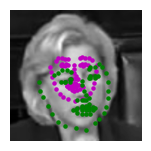

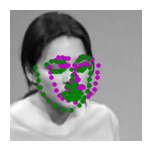

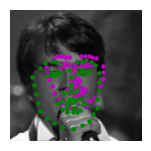

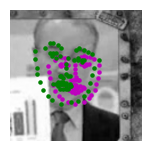

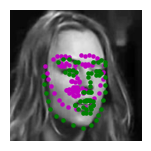

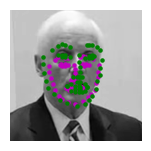

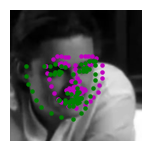

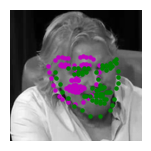

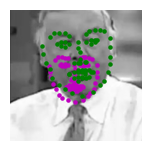

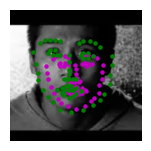

In [19]:
# visualize the output
# by default this shows a batch of 10 images
def visualize_output(test_images, test_outputs, gt_pts=None, batch_size=10):

    for i in range(batch_size):
        plt.figure(figsize=(20,10))
        ax = plt.subplot(1, batch_size, i+1)
        
        # un-transform the image data
        image = test_images[i].data   # get the image from it's Variable wrapper
        image = image.cpu()
        image = image.numpy()   # convert to numpy array from a Tensor
        image = np.transpose(image, (1, 2, 0))   # transpose to go from torch to numpy image

        # un-transform the predicted key_pts data
        predicted_key_pts = test_outputs[i].data
        predicted_key_pts = predicted_key_pts.cpu()
        predicted_key_pts = predicted_key_pts.numpy()
        # undo normalization of keypoints  
        predicted_key_pts = predicted_key_pts*50.0+100
        
        # plot ground truth points for comparison, if they exist
        ground_truth_pts = None
        if gt_pts is not None:
            ground_truth_pts = gt_pts[i].data.cpu().numpy()         
            ground_truth_pts = ground_truth_pts*50.0+100
        
        # call show_all_keypoints
        show_all_keypoints(np.squeeze(image), predicted_key_pts, ground_truth_pts)
            
        plt.axis('off')

    plt.show()

test_images, test_outputs, gt_pts = net_sample_output(train_loader)
print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())
visualize_output(test_images, test_outputs, gt_pts)

Image name:  Luis_Fonsi_21.jpg
Landmarks shape:  (68, 2)
First 4 key pts: [[ 45.  98.]
 [ 47. 106.]
 [ 49. 110.]
 [ 53. 119.]]


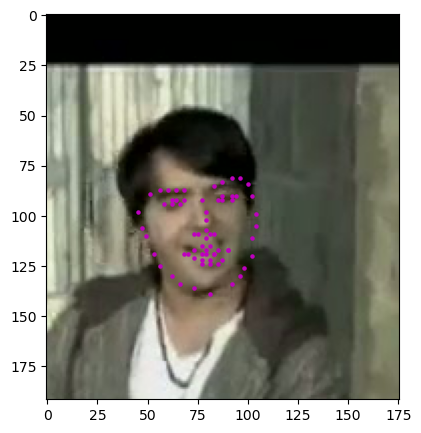

In [20]:
# import the required libraries
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
key_pts_frame = pd.read_csv(f'{root}/data/training_frames_keypoints.csv')

def show_keypoints(image, key_pts):
    """Show image with keypoints"""
    plt.imshow(image)
    plt.scatter(key_pts[:, 0], key_pts[:, 1], s=20, marker='.', c='m')
    
n = 0
image_name = key_pts_frame.iloc[n, 0]
key_pts = key_pts_frame.iloc[n, 1:].values
key_pts = key_pts.astype('float').reshape(-1, 2)

print('Image name: ', image_name)
print('Landmarks shape: ', key_pts.shape)
print('First 4 key pts: {}'.format(key_pts[:4]))

n = 0
image_name = key_pts_frame.iloc[n, 0]
key_pts = key_pts_frame.iloc[n, 1:].values
key_pts = key_pts.astype('float').reshape(-1, 2)

plt.figure(figsize=(5, 5))
show_keypoints(mpimg.imread(os.path.join(f'{root}/data/training/', image_name)), key_pts)
plt.show()

In [21]:
def test_std():
    outputs_long = torch.zeros((0,68,2))
    for i in range(10):
        test_images, test_outputs, gt_pts = net_sample_output(train_loader)
        test_outputs = test_outputs.cpu()
        outputs_long = torch.cat((outputs_long, test_outputs))
    outputs_np = outputs_long.detach().numpy().reshape((320,-1))
    std_max = outputs_np.std(axis = 0).max()
    return std_max

In [22]:
test_std()

0.11626245

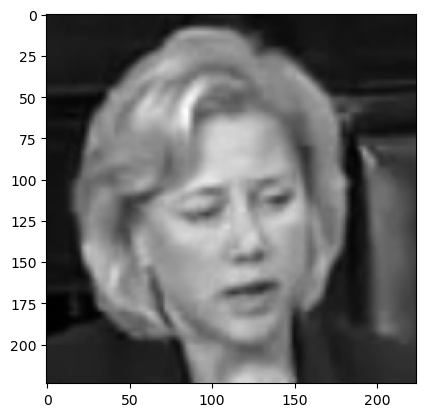

In [23]:
test_images = test_images.detach().cpu().numpy()
plt.imshow(test_images[0,0,:,:],cmap='gray')

In [24]:
## TODO: Define the loss and optimization
import torch.optim as optim

criterion = torch.nn.MSELoss()

optimizer = optim.Adam(net.parameters())


In [41]:
# Show unnormalized range of all 68 keypoints (pixel coordinates)
print("=" * 100)
print("UNNORMALIZED RANGE FOR ALL 68 KEYPOINTS (Pixel Coordinates)")
print("=" * 100)

net.eval()
all_outputs = []
sample_count = 0

# Collect predictions from approximately 200 images
with torch.no_grad():
    for batch in train_loader:
        images = batch['image'].to(device).float()
        outputs = net(images)
        all_outputs.append(outputs)
        sample_count += images.size(0)
        
        if sample_count >= 200:
            break

# Concatenate all outputs
all_outputs = torch.cat(all_outputs)
print(f"\nTotal samples analyzed: {all_outputs.shape[0]}\n")

# Convert to pixel space: pixel = normalized * 50 + 100
all_outputs_pixels = all_outputs.cpu().numpy() * 50.0 + 100

# Calculate min, max, mean, std for each coordinate
print(f"{'KP#':<5} {'Axis':<5} {'Min (px)':<12} {'Max (px)':<12} {'Range':<12} {'Mean (px)':<12} {'Std Dev':<12}")
print("-" * 100)

for i in range(0, 136, 2):
    keypoint_idx = i // 2
    
    # X coordinate
    x_vals = all_outputs_pixels[:, i]
    x_min, x_max = x_vals.min(), x_vals.max()
    x_range = x_max - x_min
    x_mean, x_std = x_vals.mean(), x_vals.std()
    
    # Y coordinate
    y_vals = all_outputs_pixels[:, i+1]
    y_min, y_max = y_vals.min(), y_vals.max()
    y_range = y_max - y_min
    y_mean, y_std = y_vals.mean(), y_vals.std()
    
    print(f"{keypoint_idx:<5} X {x_min:<11.2f} {x_max:<11.2f} {x_range:<11.2f} {x_mean:<11.2f} {x_std:<11.2f}")
    print(f"     Y {y_min:<11.2f} {y_max:<11.2f} {y_range:<11.2f} {y_mean:<11.2f} {y_std:<11.2f}")

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

# Overall statistics
all_pixels = all_outputs_pixels.flatten()
print(f"\nOverall keypoint range across all samples:")
print(f"  Min pixel value: {all_pixels.min():.2f}")
print(f"  Max pixel value: {all_pixels.max():.2f}")
print(f"  Image size: 224×224 pixels")
print(f"  Expected normalized range: [0, 224]")

# Find which keypoints vary most and least
per_coord_range = np.array([all_outputs_pixels[:, i].max() - all_outputs_pixels[:, i].min() for i in range(136)])
most_variable_idx = per_coord_range.argmax()
least_variable_idx = per_coord_range.argmin()

most_variable_kp = most_variable_idx // 2
most_variable_axis = 'X' if most_variable_idx % 2 == 0 else 'Y'
least_variable_kp = least_variable_idx // 2
least_variable_axis = 'X' if least_variable_idx % 2 == 0 else 'Y'

print(f"\nMost variable: Keypoint {most_variable_kp} ({most_variable_axis}): range = {per_coord_range[most_variable_idx]:.2f} pixels")
print(f"Least variable: Keypoint {least_variable_kp} ({least_variable_axis}): range = {per_coord_range[least_variable_idx]:.2f} pixels")


UNNORMALIZED RANGE FOR ALL 68 KEYPOINTS (Pixel Coordinates)

Total samples analyzed: 224

KP#   Axis  Min (px)     Max (px)     Range        Mean (px)    Std Dev     
----------------------------------------------------------------------------------------------------
0     X 53.28       70.32       17.04       62.96       3.40       
     Y 95.47       97.11       1.64        96.31       0.29       
1     X 55.71       71.58       15.87       64.64       3.17       
     Y 105.28      108.78      3.50        106.86      0.70       
2     X 59.23       73.73       14.50       67.23       2.91       
     Y 113.18      120.43      7.25        116.46      1.44       
3     X 65.40       77.05       11.65       71.57       2.38       
     Y 123.15      135.07      11.92       128.55      2.41       
4     X 70.05       80.48       10.43       75.77       2.10       
     Y 131.87      148.95      17.08       139.20      3.41       
5     X 79.60       85.85       6.24        82.75       1

In [40]:
# Analyze variance per keypoint over ~200 images
print("=" * 80)
print("VARIANCE PER KEYPOINT (Over ~200 Images)")
print("=" * 80)

net.eval()
all_outputs = []
sample_count = 0

# Collect predictions from approximately 200 images
with torch.no_grad():
    for batch in train_loader:
        images = batch['image'].to(device).float()
        outputs = net(images)
        all_outputs.append(outputs)
        sample_count += images.size(0)
        
        if sample_count >= 200:
            break

# Concatenate all outputs: shape [~200, 136]
all_outputs = torch.cat(all_outputs)
print(f"\nTotal samples analyzed: {all_outputs.shape[0]}")

# Calculate variance per output value (136 values = 68 keypoints × 2 coordinates)
output_variance = all_outputs.var(dim=0)  # variance across samples for each output
output_std = output_variance.sqrt()

# Convert to pixel space
# The keypoints are normalized as: (pixel - 100) / 50
# So to convert variance back to pixels: variance_pixels = variance_normalized * (50^2)
variance_pixels = output_variance * (50.0 ** 2)
std_pixels = output_std * 50.0

print(f"\nPer-Keypoint Analysis (showing X and Y coordinates):")
print(f"{'KP#':<5} {'Axis':<5} {'Var(norm)':<12} {'Std(norm)':<12} {'Var(px)':<12} {'Std(px)':<12}")
print("-" * 65)

for i in range(0, min(136, 20), 2):  # Show first 10 keypoints
    keypoint_idx = i // 2
    x_var = output_variance[i].item()
    y_var = output_variance[i+1].item()
    x_std = output_std[i].item()
    y_std = output_std[i+1].item()
    x_var_px = variance_pixels[i].item()
    y_var_px = variance_pixels[i+1].item()
    x_std_px = std_pixels[i].item()
    y_std_px = std_pixels[i+1].item()
    
    print(f"{keypoint_idx:<5} X {x_var:<11.6f} {x_std:<11.6f} {x_var_px:<11.2f} {x_std_px:<11.2f}")
    print(f"     Y {y_var:<11.6f} {y_std:<11.6f} {y_var_px:<11.2f} {y_std_px:<11.2f}")

print("\n" + "=" * 80)
print("OVERALL SUMMARY")
print("=" * 80)
print(f"\nNormalized variance (0-1 scale):")
print(f"  Mean: {output_variance.mean().item():.6f}")
print(f"  Min:  {output_variance.min().item():.6f}")
print(f"  Max:  {output_variance.max().item():.6f}")

print(f"\nPixel space (224×224 image):")
print(f"  Mean variance: {variance_pixels.mean().item():.2f} pixels²")
print(f"  Mean std dev: {std_pixels.mean().item():.2f} pixels")
print(f"  Range: ±{std_pixels.min().item():.2f} to ±{std_pixels.max().item():.2f} pixels")

print(f"\nInterpretation:")
print(f"  ✓ Average keypoint varies by ±{std_pixels.mean().item():.1f} pixels across 200 faces")
print(f"  ✓ This is ~{std_pixels.mean().item()/224*100:.1f}% of image width")


VARIANCE PER KEYPOINT (Over ~200 Images)

Total samples analyzed: 224

Per-Keypoint Analysis (showing X and Y coordinates):
KP#   Axis  Var(norm)    Std(norm)    Var(px)      Std(px)     
-----------------------------------------------------------------
0     X 0.004598    0.067808    11.49       3.39       
     Y 0.000033    0.005774    0.08        0.29       
1     X 0.003986    0.063133    9.96        3.16       
     Y 0.000197    0.014040    0.49        0.70       
2     X 0.003365    0.058006    8.41        2.90       
     Y 0.000830    0.028805    2.07        1.44       
3     X 0.002237    0.047300    5.59        2.37       
     Y 0.002299    0.047943    5.75        2.40       
4     X 0.001746    0.041780    4.36        2.09       
     Y 0.004625    0.068004    11.56       3.40       
5     X 0.000554    0.023527    1.38        1.18       
     Y 0.007714    0.087831    19.29       4.39       
6     X 0.000384    0.019597    0.96        0.98       
     Y 0.009576    0.097

In [37]:
# IMPORTANT: Check which model you're using
print("=" * 60)
print("MODEL STATE CHECK")
print("=" * 60)
print("\nModel file being loaded in cell 2:")
print("  saved_models/keypoints_model_2_layers.pt")
print("\nThis is a PRE-TRAINED model from an earlier run.")
print("\nTo see improvements from training, you need to:")
print("  1. Train with: train_net(n_epochs)")
print("  2. Then SAVE with: torch.save(net.state_dict(), 'saved_models/keypoints_model_NEW.pt')")
print("  3. Then LOAD that saved model")
print("\nAre you running the train_net() cell with the new fixed code?")
print("  That's in the cell before 'Test data' section")


MODEL STATE CHECK

Model file being loaded in cell 2:
  saved_models/keypoints_model_2_layers.pt

This is a PRE-TRAINED model from an earlier run.

To see improvements from training, you need to:
  1. Train with: train_net(n_epochs)
  2. Then SAVE with: torch.save(net.state_dict(), 'saved_models/keypoints_model_NEW.pt')
  3. Then LOAD that saved model

Are you running the train_net() cell with the new fixed code?
  That's in the cell before 'Test data' section


In [36]:
# Check predicted keypoints range and variance
print("=" * 60)
print("KEYPOINT RANGE CHECK")
print("=" * 60)

net.eval()
all_outputs = []

with torch.no_grad():
    for i, batch in enumerate(train_loader):
        if i >= 5:  # Check first 5 batches
            break
        images = batch['image'].to(device).float()
        outputs = net(images)
        all_outputs.append(outputs)

all_outputs = torch.cat(all_outputs)  # Shape: [160, 136]
print(f"\nTotal samples analyzed: {all_outputs.shape[0]}")
print(f"Output range (raw): [{all_outputs.min().item():.4f}, {all_outputs.max().item():.4f}]")

# Un-normalize to see pixel coordinates
unnormalized = all_outputs.cpu().numpy() * 50.0 + 100
print(f"Unnormalized range: [{unnormalized.min():.2f}, {unnormalized.max():.2f}]")

# Check variance per keypoint
output_variance = all_outputs.var(dim=0)
print(f"\nKeypoint variance (raw):")
print(f"  Min variance: {output_variance.min().item():.6f}")
print(f"  Max variance: {output_variance.max().item():.6f}")
print(f"  Mean variance: {output_variance.mean().item():.6f}")

# If variance is too low, model might be collapsing
if output_variance.mean().item() < 0.001:
    print("\n⚠️  WARNING: Very low variance - model might be collapsing to a mean output!")
else:
    print("\n✓ Variance looks reasonable - model is producing varied outputs")


KEYPOINT RANGE CHECK

Total samples analyzed: 160
Output range (raw): [-1.1520, 2.7790]
Unnormalized range: [42.40, 238.95]

Keypoint variance (raw):
  Min variance: 0.000712
  Max variance: 0.156882
  Mean variance: 0.057633

✓ Variance looks reasonable - model is producing varied outputs


In [35]:
# Deep diagnostic: Check if model is actually learning
print("=" * 60)
print("DEEP DIAGNOSTIC: Model Learning Check")
print("=" * 60)

# 1. Check if model has trainable parameters
total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

# 2. Check gradient flow
net.train()
sample_batch = next(iter(train_loader))
images = sample_batch['image'].to(device).float()
key_pts = sample_batch['keypoints'].to(device).float().view(images.size(0), -1)

# Forward pass
output_pts = net(images)
loss = criterion(output_pts, key_pts)

print(f"\nLoss value: {loss.item():.6f}")
print(f"Output shape: {output_pts.shape}")
print(f"Output range: [{output_pts.min().item():.4f}, {output_pts.max().item():.4f}]")
print(f"Target range: [{key_pts.min().item():.4f}, {key_pts.max().item():.4f}]")

# Check if gradients are flowing
optimizer.zero_grad()
loss.backward()

# Check if gradients exist and are non-zero
grad_norms = []
for name, param in net.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        grad_norms.append(grad_norm)
        if grad_norm == 0:
            print(f"WARNING: {name} has zero gradients!")

print(f"\nGradient flow check: {len(grad_norms)} layers have gradients")
print(f"Mean gradient norm: {np.mean(grad_norms):.6f}")

# 3. Check if model is producing different outputs
net.eval()
with torch.no_grad():
    batch_outputs = []
    for i in range(3):
        batch = next(iter(train_loader))
        batch_img = batch['image'][:5].to(device).float()  # 5 different images
        outputs = net(batch_img)
        batch_outputs.append(outputs)
        
        print(f"\nBatch {i+1} outputs (first 5 samples, first 10 values):")
        print(outputs[:, :10])
        
        # Check if all outputs in batch are identical
        all_same = torch.allclose(outputs[0], outputs[1])
        print(f"Are samples identical in batch? {all_same}")


DEEP DIAGNOSTIC: Model Learning Check

Total parameters: 744288488
Trainable parameters: 744288488

Loss value: 0.109301
Output shape: torch.Size([32, 136])
Output range: [-1.0531, 2.3115]
Target range: [-1.2474, 2.4953]

Gradient flow check: 12 layers have gradients
Mean gradient norm: 0.142966

Batch 1 outputs (first 5 samples, first 10 values):
tensor([[-1.1297,  0.3426, -1.0994,  0.7044, -1.0309,  1.0424, -0.9704,  1.3606,
         -0.8573,  1.6894],
        [-0.8657,  0.2537, -0.8463,  0.5353, -0.7889,  0.7955, -0.7468,  1.0466,
         -0.6606,  1.3036],
        [-0.7226,  0.1253, -0.7089,  0.3589, -0.6610,  0.5763, -0.6213,  0.7991,
         -0.5466,  1.0142],
        [-0.5944, -0.0274, -0.5880,  0.1667, -0.5499,  0.3480, -0.5117,  0.5396,
         -0.4469,  0.7261],
        [-0.9343, -0.1392, -0.8958,  0.1560, -0.8524,  0.4422, -0.7866,  0.7237,
         -0.6861,  1.0026]], device='cuda:0')
Are samples identical in batch? False

Batch 2 outputs (first 5 samples, first 10 value

In [25]:
# Diagnostic: Check data loading and device handling
print("Device:", device)
print("Model device:", next(net.parameters()).device)

# Test with one batch
sample_batch = next(iter(train_loader))
print("\nBatch shapes:")
print(f"Images shape: {sample_batch['image'].shape}")
print(f"Images dtype: {sample_batch['image'].dtype}")
print(f"Images device: {sample_batch['image'].device}")
print(f"Keypoints shape: {sample_batch['keypoints'].shape}")

# Test forward pass with proper device handling
images_test = sample_batch['image'].to(device).float()
print(f"\nAfter .to(device).float():")
print(f"Images dtype: {images_test.dtype}")
print(f"Images device: {images_test.device}")

# Quick forward pass test
net.eval()
with torch.no_grad():
    out1 = net(sample_batch['image'][:2].to(device).float())
    out2 = net(sample_batch['image'][2:4].to(device).float())
    print(f"\nOutput 1 (first 2 samples):\n{out1[:, :10]}")
    print(f"Output 2 (next 2 samples):\n{out2[:, :10]}")
    print(f"Are outputs the same? {torch.allclose(out1, out2)}")


Device: cuda
Model device: cuda:0

Batch shapes:
Images shape: torch.Size([32, 1, 224, 224])
Images dtype: torch.float32
Images device: cpu
Keypoints shape: torch.Size([32, 68, 2])

After .to(device).float():
Images dtype: torch.float32
Images device: cuda:0

Output 1 (first 2 samples):
tensor([[-0.7207, -0.0719, -0.6881,  0.1328, -0.6380,  0.3199, -0.5531,  0.5559,
         -0.4716,  0.7639],
        [-0.7699, -0.0819, -0.7384,  0.1459, -0.6880,  0.3488, -0.6065,  0.6009,
         -0.5099,  0.8119]], device='cuda:0')
Output 2 (next 2 samples):
tensor([[-0.7118, -0.0739, -0.6816,  0.1322, -0.6328,  0.3194, -0.5546,  0.5536,
         -0.4692,  0.7544],
        [-0.7251, -0.0630, -0.6885,  0.1295, -0.6342,  0.3131, -0.5352,  0.5479,
         -0.4658,  0.7710]], device='cuda:0')
Are outputs the same? False


In [26]:
def train_net(n_epochs):

    # prepare the net for training
    net.train()

    for epoch in range(n_epochs):  # loop over the dataset multiple times
        
        running_loss = 0.0

        # train on batches of data, assumes you already have train_loader
        for batch_i, data in enumerate(train_loader):
            # get the input images and their corresponding labels
            # Use .to(device) and .float() instead of .type(torch.cuda.FloatTensor)
            # This ensures device compatibility whether on CPU or GPU
            images = data['image'].to(device).float()
            key_pts = data['keypoints'].to(device).float()

            # flatten pts
            key_pts = key_pts.view(key_pts.size(0), -1)

            # forward pass to get outputs
            output_pts = net(images)

            # calculate the loss between predicted and target keypoints
            loss = criterion(output_pts, key_pts)

            # zero the parameter (weight) gradients
            optimizer.zero_grad()
            
            # backward pass to calculate the weight gradients
            loss.backward()

            # update the weights
            optimizer.step()

            # print loss statistics
            running_loss += loss.item()
            if batch_i % 10 == 9:    # print every 10 batches
                print('Epoch: {}, Batch: {}, Avg. Loss: {}'.format(epoch + 1, batch_i+1, running_loss/10))
                running_loss = 0.0

    print('Finished Training')

In [27]:
# train your network
n_epochs = 3 # start small, and increase when you've decided on your model structure and hyperparams

# this is a Workspaces-specific context manager to keep the connection
# alive while training your model, not part of pytorch

train_net(n_epochs)

Epoch: 1, Batch: 10, Avg. Loss: 0.7600852981209755
Epoch: 1, Batch: 20, Avg. Loss: 0.5113764584064484
Epoch: 1, Batch: 30, Avg. Loss: 0.28752984553575517
Epoch: 1, Batch: 40, Avg. Loss: 0.21734216511249543
Epoch: 1, Batch: 50, Avg. Loss: 0.20369219332933425
Epoch: 1, Batch: 60, Avg. Loss: 0.2069636732339859
Epoch: 1, Batch: 70, Avg. Loss: 0.19463174194097518
Epoch: 1, Batch: 80, Avg. Loss: 0.16003101617097854
Epoch: 1, Batch: 90, Avg. Loss: 0.18312608748674392
Epoch: 1, Batch: 100, Avg. Loss: 0.20293979495763778
Epoch: 2, Batch: 10, Avg. Loss: 0.16825621500611304
Epoch: 2, Batch: 20, Avg. Loss: 0.2176643043756485
Epoch: 2, Batch: 30, Avg. Loss: 0.1730121836066246
Epoch: 2, Batch: 40, Avg. Loss: 0.17541043534874917
Epoch: 2, Batch: 50, Avg. Loss: 0.17882601916790009
Epoch: 2, Batch: 60, Avg. Loss: 0.15550294145941734
Epoch: 2, Batch: 70, Avg. Loss: 0.16717175170779228
Epoch: 2, Batch: 80, Avg. Loss: 0.16798465326428413
Epoch: 2, Batch: 90, Avg. Loss: 0.14096586406230927
Epoch: 2, Batch:

## Test data

See how your model performs on previously unseen, test data. We've already loaded and transformed this data, similar to the training data. Next, run your trained model on these images to see what kind of keypoints are produced. You should be able to see if your model is fitting each new face it sees, if the points are distributed randomly, or if the points have actually overfitted the training data and do not generalize.

In [31]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output()

print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())

torch.Size([32, 1, 224, 224])
torch.Size([32, 68, 2])
torch.Size([32, 68, 2])


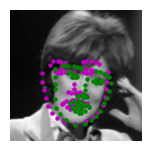

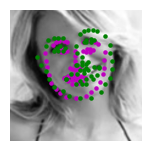

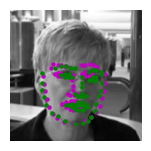

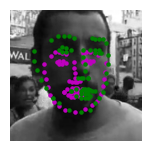

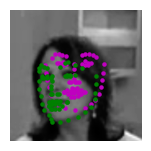

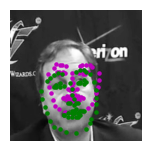

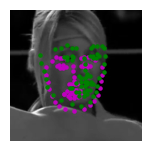

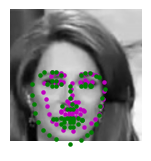

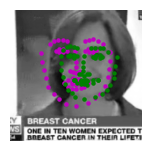

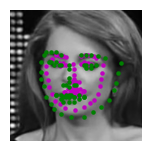

In [32]:
## TODO: visualize your test output
# you can use the same function as before, by un-commenting the line below:

visualize_output(test_images, test_outputs, gt_pts)


In [33]:
# get a sample of test data again
test_images2, test_outputs2, gt_pts2 = net_sample_output(train_loader)

print(test_images2.data.size())
print(test_outputs2.data.size())
print(gt_pts2.size())

torch.Size([32, 1, 224, 224])
torch.Size([32, 68, 2])
torch.Size([32, 68, 2])


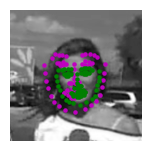

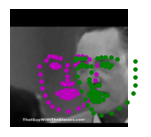

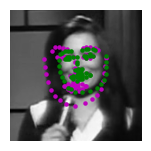

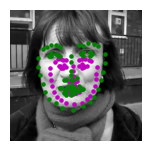

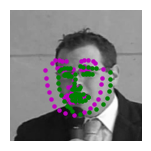

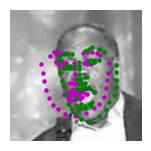

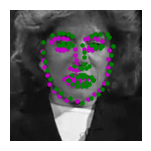

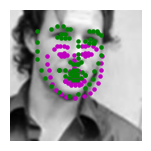

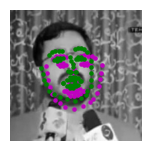

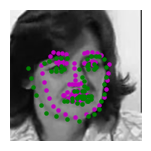

In [34]:
visualize_output(test_images2, test_outputs2, gt_pts2)


Once you've found a good model (or two), save your model so you can load it and use it later!

Save your models but please **delete any checkpoints and saved models before you submit your project** otherwise your workspace may be too large to submit.

In [18]:
## TODO: change the name to something uniqe for each new model
model_dir = 'saved_models/'
model_name = 'keypoints_model_1.pt'

# after training, save your model parameters in the dir 'saved_models'
torch.save(net.state_dict(), model_dir+model_name)

After you've trained a well-performing model, answer the following questions so that we have some insight into your training and architecture selection process. Answering all questions is required to pass this project.

### Question 1: What optimization and loss functions did you choose and why?


**Answer**: Optimizer: Adam | It is faster than SGD and gives similar results for this purpose.
Loss function: MSELoss | L1Loss worked well too. I chose MSE because with L1Loss, an error of [5, 5, 5] is as bad as [1, 2, 12]. For face detection, the later seems worse. MSE clearly make the distinction and will penalize the later case more.

### Question 2: What kind of network architecture did you start with and how did it change as you tried different architectures? Did you decide to add more convolutional layers or any layers to avoid overfitting the data?

**Answer**: I started with the most basic - Only one convolutional layer with large kernels. That did not work well. Then I experimented with one convolutional layer and one fully-connected layer. That improved the results.
So I went on to experiment with more convolutional layers, fully connected layers and dropout layers. 
I automated the hyperparameter tuning process and found that the architecture that I have used in this notebook was giving the best results. Dropout of 0.1 - 0.2 works best - takes almost the same time to train, and removes overfitting to a degree. Fully connected layers should be around 256 - 1000 neurons wide. Making them any bigger, did not improve the accuracy. Adding a 5th fully connected layer to the existing 4 also did not improve the accuracy. For the convolution layers, kernel size of 3 to 7 worked best. I also added MaxPool2D layers to decrease overfitting and decrease the number of features coming out of the convolutional layers.

### Question 3: How did you decide on the number of epochs and batch_size to train your model?

**Answer**: I start with 1. If the resultas are interesting I go for further iterations. My laptop supported 20 workers, so I used 32 as the batch_size. That made the training faster. 

## Feature Visualization

Sometimes, neural networks are thought of as a black box, given some input, they learn to produce some output. CNN's are actually learning to recognize a variety of spatial patterns and you can visualize what each convolutional layer has been trained to recognize by looking at the weights that make up each convolutional kernel and applying those one at a time to a sample image. This technique is called feature visualization and it's useful for understanding the inner workings of a CNN.

In the cell below, you can see how to extract a single filter (by index) from your first convolutional layer. The filter should appear as a grayscale grid.

[[ 0.182574   -0.27906692 -0.11082625]
 [ 0.01240154  0.17921345 -0.07769096]
 [ 0.13160646 -0.21726482  0.10427248]]
(3, 3)


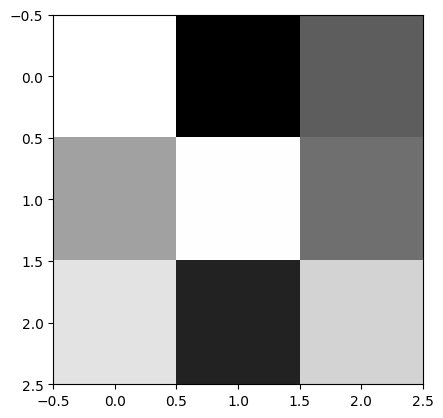

In [19]:
# Get the weights in the first conv layer, "conv1"
# if necessary, change this to reflect the name of your first conv layer
weights1 = net.conv1.weight.data.cpu()

w = weights1.numpy()

filter_index = 0

print(w[filter_index][0])
print(w[filter_index][0].shape)

# display the filter weights
plt.imshow(w[filter_index][0], cmap='gray')


## Feature maps

Each CNN has at least one convolutional layer that is composed of stacked filters (also known as convolutional kernels). As a CNN trains, it learns what weights to include in it's convolutional kernels and when these kernels are applied to some input image, they produce a set of **feature maps**. So, feature maps are just sets of filtered images; they are the images produced by applying a convolutional kernel to an input image. These maps show us the features that the different layers of the neural network learn to extract. For example, you might imagine a convolutional kernel that detects the vertical edges of a face or another one that detects the corners of eyes. You can see what kind of features each of these kernels detects by applying them to an image. One such example is shown below; from the way it brings out the lines in an the image, you might characterize this as an edge detection filter.

<img src='images/feature_map_ex.png' width=50% height=50%/>


Next, choose a test image and filter it with one of the convolutional kernels in your trained CNN; look at the filtered output to get an idea what that particular kernel detects.

### TODO: Filter an image to see the effect of a convolutional kernel
---

In [20]:
##TODO: load in and display any image from the transformed test dataset

## TODO: Using cv's filter2D function,
## apply a specific set of filter weights (like the one displayed above) to the test image


### Question 4: Choose one filter from your trained CNN and apply it to a test image; what purpose do you think it plays? What kind of feature do you think it detects?


**Answer**: (does it detect vertical lines or does it blur out noise, etc.) write your answer here

---
## Moving on!

Now that you've defined and trained your model (and saved the best model), you are ready to move on to the last notebook, which combines a face detector with your saved model to create a facial keypoint detection system that can predict the keypoints on *any* face in an image!